# Assignment 2: The Cost of Being Wrong

## 1. Data & Reproducibility

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)

# Load data
df = pd.read_csv('../AML_Book-Data/Data/a1_cleaned_data.csv')
df['ts'] = pd.to_datetime(df['ts'])
df.sort_values('ts', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Time range: {df['ts'].min()} to {df['ts'].max()}")


Data loaded: 180000 rows, 38 columns
Time range: 2025-02-06 00:46:00 to 2026-07-31 22:11:42


## 2. Data Validation
Verify what `is_fraud` represents. In this synthetic mobile-money context, fraud means bad/stolen transactions, which is analogous to a 'default' (a bad event we want to avoid). We treat `is_fraud = 1` as the positive class (missed default cost = 10,000) and `is_fraud = 0` as the negative class (wrongly rejected good transaction cost = 800).

In [2]:
print("Target distribution:")
print(df['is_fraud'].value_counts(normalize=True))

# Identify numerical and categorical features
LEAKY_COLS = ['manual_review_score', 'settlement_status']
TARGET = 'is_fraud'
TIME_COL = 'ts'
GROUP_COL = 'customer_id'

IGNORE_COLS = ['txn_id', 'msisdn', 'reg_id', 'account_name', 'agent_id', 'device_id', 'counterparty', 'amount', 'gps_lat', 'gps_lon', 'balance_after', 'amount_signed'] + LEAKY_COLS + [TARGET, TIME_COL, GROUP_COL]
FEATURES = [c for c in df.columns if c not in IGNORE_COLS]
NUMERICAL = ['amount_abs', 'log_amt', 'hr_sin', 'hr_cos', 'dow_sin', 'dow_cos', 'payday_dist', 'gps_missing', 'recency_days', 'frequency', 'monetary_out', 'monetary_in', 'n_counterparty', 'cashout_ratio', 'out_in_ratio']
CATEGORICAL = ['txn_type', 'region', 'segment']

print(f"Using {len(FEATURES)} features.")


Target distribution:
is_fraud
0    0.915922
1    0.084078
Name: proportion, dtype: float64
Using 21 features.


## 3. Temporal Split
Strict chronological split: Earliest 80% for Development, Latest 20% for Final Test (Locked).

In [3]:
split_idx = int(len(df) * 0.8)
split_date = df['ts'].iloc[split_idx]
print(f"Split Date: {split_date}")

# Ensure we don't split in the middle of a day or timestamp exactly, but here we just strictly split by time
dev_df = df[df['ts'] < split_date].copy()
test_df = df[df['ts'] >= split_date].copy()

print(f"Development Set: {len(dev_df)} rows")
print(f"Final Test Set: {len(test_df)} rows (LOCKED until the very end)")


Split Date: 2026-04-14 09:26:42
Development Set: 144000 rows
Final Test Set: 36000 rows (LOCKED until the very end)


## 4. Purged CV Design
Custom Group-Aware Purged Time-Series CV. We ensure that customer groups are disjoint across folds and respect time ordering. We will use a rolling window or blocked approach.

In [4]:
from sklearn.model_selection import TimeSeriesSplit

class GroupTimeSeriesSplit:
    '''Custom CV that splits by time while ensuring groups do not overlap between train and test. 
       Actually, to strictly prevent future peaking, test must be strictly after train.
       To avoid group leakage, if a customer is in test, their past data can't be in train.
       We implement a simple blocked time split, and purge any overlapping customers from train.'''
    def __init__(self, n_splits=5):
        self.n_splits = n_splits
        
    def split(self, X, y=None, groups=None):
        tscv = TimeSeriesSplit(n_splits=self.n_splits)
        for train_idx, test_idx in tscv.split(X):
            train_groups = set(groups.iloc[train_idx])
            test_groups = set(groups.iloc[test_idx])
            
            # Purge any train index whose group is in test
            overlap = train_groups.intersection(test_groups)
            
            clean_train_idx = [i for i in train_idx if groups.iloc[i] not in overlap]
            yield np.array(clean_train_idx), test_idx

cv = GroupTimeSeriesSplit(n_splits=3)
# Let's test it
X_dev = dev_df[FEATURES]
y_dev = dev_df[TARGET]
groups_dev = dev_df[GROUP_COL]

for i, (tr, te) in enumerate(cv.split(X_dev, y_dev, groups_dev)):
    tr_groups = set(groups_dev.iloc[tr])
    te_groups = set(groups_dev.iloc[te])
    intersect = tr_groups.intersection(te_groups)
    
    tr_max_time = dev_df['ts'].iloc[tr].max()
    te_min_time = dev_df['ts'].iloc[te].min()
    print(f"Fold {i+1}: Train={len(tr)}, Val={len(te)} | Overlap={len(intersect)} | TrainMax={tr_max_time}, ValMin={te_min_time}")


Fold 1: Train=200, Val=36000 | Overlap=0 | TrainMax=2025-05-25 12:36:00, ValMin=2025-05-25 13:39:00


Fold 2: Train=509, Val=36000 | Overlap=0 | TrainMax=2025-09-11 11:24:00, ValMin=2025-09-11 22:02:34


Fold 3: Train=561, Val=36000 | Overlap=0 | TrainMax=2025-12-27 11:50:00, ValMin=2025-12-28 08:35:26


## 5. Baseline Models
Compare Logistic Regression, Random Forest, and LightGBM.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
import time

def build_preprocessor():
    num = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', RobustScaler()),
    ])
    cat = Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='UNK')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    return ColumnTransformer([('num', num, NUMERICAL), ('cat', cat, CATEGORICAL)])

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1, verbose=-1)
}

results = []

for name, clf in models.items():
    pipe = Pipeline([('prep', build_preprocessor()), ('clf', clf)])
    
    pr_aucs = []
    roc_aucs = []
    
    t0 = time.time()
    for tr, te in cv.split(X_dev, y_dev, groups_dev):
        X_tr, y_tr = X_dev.iloc[tr], y_dev.iloc[tr]
        X_te, y_te = X_dev.iloc[te], y_dev.iloc[te]
        
        pipe.fit(X_tr, y_tr)
        preds = pipe.predict_proba(X_te)[:, 1]
        
        pr_aucs.append(average_precision_score(y_te, preds))
        roc_aucs.append(roc_auc_score(y_te, preds))
        
    t1 = time.time()
    results.append({
        'Model': name,
        'Mean PR-AUC': np.mean(pr_aucs),
        'Mean ROC-AUC': np.mean(roc_aucs),
        'Time (s)': t1 - t0
    })

baseline_df = pd.DataFrame(results)
display(baseline_df)


,Model,Mean PR-AUC,Mean ROC-AUC,Time (s)
0,Logistic Regression,0.090150,0.526389,3.858024
1,Random Forest,0.088249,0.514535,4.554632
2,LightGBM,0.086194,0.514200,2.640909


## 6. Imbalance Experiments
Compare Baseline vs Class Weighting vs SMOTE for the best model (e.g. LightGBM or Logistic Regression).

In [6]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Let's say LightGBM was best, or we use LightGBM for speed
lgb_base = LGBMClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1, verbose=-1)
lgb_cw = LGBMClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
smote = SMOTE(random_state=42)

pipelines = {
    'Baseline': Pipeline([('prep', build_preprocessor()), ('clf', lgb_base)]),
    'Class Weighting': Pipeline([('prep', build_preprocessor()), ('clf', lgb_cw)]),
    'SMOTE (Inside Fold)': ImbPipeline([('prep', build_preprocessor()), ('smote', smote), ('clf', lgb_base)])
}

imb_results = []
for name, pipe in pipelines.items():
    pr_aucs = []
    for tr, te in cv.split(X_dev, y_dev, groups_dev):
        X_tr, y_tr = X_dev.iloc[tr], y_dev.iloc[tr]
        X_te, y_te = X_dev.iloc[te], y_dev.iloc[te]
        pipe.fit(X_tr, y_tr)
        preds = pipe.predict_proba(X_te)[:, 1]
        pr_aucs.append(average_precision_score(y_te, preds))
    imb_results.append({'Strategy': name, 'Mean PR-AUC': np.mean(pr_aucs)})
    
print("Imbalance Handling Results:")
display(pd.DataFrame(imb_results))


Imbalance Handling Results:


,Strategy,Mean PR-AUC
0,Baseline,0.086194
1,Class Weighting,0.086458
2,SMOTE (Inside Fold),0.089956


## 7. Leakage Demonstration
Apply SMOTE before Cross Validation to show the artificial inflation of the score.

In [7]:
# Note: This is an intentionally BAD practice.
X_dev_prep = build_preprocessor().fit_transform(X_dev)
X_resampled, y_resampled = smote.fit_resample(X_dev_prep, y_dev)

# Because we lost the original grouping during SMOTE, we must do a naive split to demonstrate standard leakage
from sklearn.model_selection import KFold
kf = KFold(n_splits=3, shuffle=False) # Naive split without time or groups

leaky_aucs = []
for tr, te in kf.split(X_resampled):
    clf = LGBMClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1, verbose=-1)
    clf.fit(X_resampled[tr], y_resampled.iloc[tr])
    preds = clf.predict_proba(X_resampled[te])[:, 1]
    leaky_aucs.append(average_precision_score(y_resampled.iloc[te], preds))

imb_results.append({'Strategy': 'SMOTE (Before CV / LEAKY)', 'Mean PR-AUC': np.mean(leaky_aucs)})

leakage_df = pd.DataFrame(imb_results)
display(leakage_df)


,Strategy,Mean PR-AUC
0,Baseline,0.086194
1,Class Weighting,0.086458
2,SMOTE (Inside Fold),0.089956
3,SMOTE (Before CV / LEAKY),0.698051


## 8. Optuna Tuning
Tune LightGBM using >=60 trials.

In [8]:
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 30.0) # Exploring class weighting
    }
    
    clf = LGBMClassifier(**params, random_state=42, n_jobs=-1, verbose=-1)
    pipe = Pipeline([('prep', build_preprocessor()), ('clf', clf)])
    
    scores = []
    for tr, te in cv.split(X_dev, y_dev, groups_dev):
        pipe.fit(X_dev.iloc[tr], y_dev.iloc[tr])
        preds = pipe.predict_proba(X_dev.iloc[te])[:, 1]
        scores.append(average_precision_score(y_dev.iloc[te], preds))
        
    return np.mean(scores)

# Uncomment below to run tuning. In practice this takes time.
study = optuna.create_study(direction='maximize', study_name='lgbm_tune', storage='sqlite:///results/optuna_study.db', load_if_exists=True)
study.optimize(objective, n_trials=60)
print('Best params:', study.best_params)

# For now we will use a dummy best_params to continue
best_params = study.best_params # {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.05, 'num_leaves': 31, 'scale_pos_weight': 12.5}
print("Using best params:", best_params)
final_clf = LGBMClassifier(**best_params, random_state=42, n_jobs=-1, verbose=-1)
final_pipe = Pipeline([('prep', build_preprocessor()), ('clf', final_clf)])


[I 2026-08-31 16:47:52,723] A new study created in RDB with name: lgbm_tune


[I 2026-08-31 16:48:22,810] Trial 0 finished with value: 0.08654509690262148 and parameters: {'n_estimators': 252, 'max_depth': 4, 'learning_rate': 0.28250185196150246, 'num_leaves': 25, 'scale_pos_weight': 19.053594721236323}. Best is trial 0 with value: 0.08654509690262148.


[I 2026-08-31 16:48:31,477] Trial 1 finished with value: 0.08571206909618716 and parameters: {'n_estimators': 106, 'max_depth': 4, 'learning_rate': 0.14507023500329017, 'num_leaves': 74, 'scale_pos_weight': 5.994609802851137}. Best is trial 0 with value: 0.08654509690262148.


[I 2026-08-31 16:48:39,587] Trial 2 finished with value: 0.08681648037744753 and parameters: {'n_estimators': 236, 'max_depth': 10, 'learning_rate': 0.011017245103761255, 'num_leaves': 55, 'scale_pos_weight': 25.808535533027836}. Best is trial 2 with value: 0.08681648037744753.


[I 2026-08-31 16:48:43,533] Trial 3 finished with value: 0.08874850488088427 and parameters: {'n_estimators': 101, 'max_depth': 5, 'learning_rate': 0.002277360340429391, 'num_leaves': 22, 'scale_pos_weight': 22.63505433628722}. Best is trial 3 with value: 0.08874850488088427.


[I 2026-08-31 16:48:48,174] Trial 4 finished with value: 0.08943743274698461 and parameters: {'n_estimators': 96, 'max_depth': 10, 'learning_rate': 0.004641022095826881, 'num_leaves': 73, 'scale_pos_weight': 18.5769468372318}. Best is trial 4 with value: 0.08943743274698461.


[I 2026-08-31 16:48:55,257] Trial 5 finished with value: 0.0901743890972742 and parameters: {'n_estimators': 263, 'max_depth': 8, 'learning_rate': 0.0015357496049314702, 'num_leaves': 45, 'scale_pos_weight': 24.003794327184963}. Best is trial 5 with value: 0.0901743890972742.


[I 2026-08-31 16:49:01,017] Trial 6 finished with value: 0.08912925913733889 and parameters: {'n_estimators': 98, 'max_depth': 5, 'learning_rate': 0.0018587249539561504, 'num_leaves': 96, 'scale_pos_weight': 4.5152701633234384}. Best is trial 5 with value: 0.0901743890972742.


[I 2026-08-31 16:49:04,003] Trial 7 finished with value: 0.08751968560399087 and parameters: {'n_estimators': 153, 'max_depth': 10, 'learning_rate': 0.2514829938595145, 'num_leaves': 82, 'scale_pos_weight': 14.76753564437019}. Best is trial 5 with value: 0.0901743890972742.


[I 2026-08-31 16:49:07,421] Trial 8 finished with value: 0.08821439207004794 and parameters: {'n_estimators': 222, 'max_depth': 7, 'learning_rate': 0.0033374861410425355, 'num_leaves': 32, 'scale_pos_weight': 3.1017364782406673}. Best is trial 5 with value: 0.0901743890972742.


[I 2026-08-31 16:49:13,110] Trial 9 finished with value: 0.08998760759698794 and parameters: {'n_estimators': 204, 'max_depth': 10, 'learning_rate': 0.0012230587127698925, 'num_leaves': 52, 'scale_pos_weight': 14.21558119700462}. Best is trial 5 with value: 0.0901743890972742.


[I 2026-08-31 16:49:18,771] Trial 10 finished with value: 0.08731797237383021 and parameters: {'n_estimators': 287, 'max_depth': 8, 'learning_rate': 0.04320181361755037, 'num_leaves': 48, 'scale_pos_weight': 29.72858469609985}. Best is trial 5 with value: 0.0901743890972742.


[I 2026-08-31 16:49:22,492] Trial 11 finished with value: 0.08986332541392765 and parameters: {'n_estimators': 178, 'max_depth': 8, 'learning_rate': 0.0011340648820007838, 'num_leaves': 49, 'scale_pos_weight': 11.244122235454853}. Best is trial 5 with value: 0.0901743890972742.


[I 2026-08-31 16:49:26,500] Trial 12 finished with value: 0.0882610630679684 and parameters: {'n_estimators': 191, 'max_depth': 8, 'learning_rate': 0.008786576600894483, 'num_leaves': 40, 'scale_pos_weight': 10.21277539190984}. Best is trial 5 with value: 0.0901743890972742.


[I 2026-08-31 16:49:31,957] Trial 13 finished with value: 0.08820991999047723 and parameters: {'n_estimators': 298, 'max_depth': 9, 'learning_rate': 0.0010479517724826868, 'num_leaves': 59, 'scale_pos_weight': 22.747375935568556}. Best is trial 5 with value: 0.0901743890972742.


[I 2026-08-31 16:49:37,324] Trial 14 finished with value: 0.08838672385025198 and parameters: {'n_estimators': 263, 'max_depth': 7, 'learning_rate': 0.00745783428195947, 'num_leaves': 64, 'scale_pos_weight': 15.38481365245548}. Best is trial 5 with value: 0.0901743890972742.


[I 2026-08-31 16:49:41,366] Trial 15 finished with value: 0.08711125807977749 and parameters: {'n_estimators': 208, 'max_depth': 9, 'learning_rate': 0.018193577728260992, 'num_leaves': 37, 'scale_pos_weight': 26.86674918150911}. Best is trial 5 with value: 0.0901743890972742.


[I 2026-08-31 16:49:45,758] Trial 16 finished with value: 0.09081425014248312 and parameters: {'n_estimators': 158, 'max_depth': 6, 'learning_rate': 0.0019813082262953616, 'num_leaves': 45, 'scale_pos_weight': 8.570978569043497}. Best is trial 16 with value: 0.09081425014248312.


[I 2026-08-31 16:49:48,685] Trial 17 finished with value: 0.09129225734823025 and parameters: {'n_estimators': 61, 'max_depth': 6, 'learning_rate': 0.0035717161442824314, 'num_leaves': 41, 'scale_pos_weight': 7.6619553286985855}. Best is trial 17 with value: 0.09129225734823025.


[I 2026-08-31 16:49:51,538] Trial 18 finished with value: 0.09109313966027299 and parameters: {'n_estimators': 51, 'max_depth': 6, 'learning_rate': 0.004580751271978681, 'num_leaves': 33, 'scale_pos_weight': 7.920310751621727}. Best is trial 17 with value: 0.09129225734823025.


[I 2026-08-31 16:49:56,805] Trial 19 finished with value: 0.08991309791357431 and parameters: {'n_estimators': 60, 'max_depth': 3, 'learning_rate': 0.025574105912510255, 'num_leaves': 31, 'scale_pos_weight': 7.537510868760524}. Best is trial 17 with value: 0.09129225734823025.


[I 2026-08-31 16:49:59,556] Trial 20 finished with value: 0.08635348181127774 and parameters: {'n_estimators': 53, 'max_depth': 6, 'learning_rate': 0.0042630121216639, 'num_leaves': 30, 'scale_pos_weight': 1.1099976425962783}. Best is trial 17 with value: 0.09129225734823025.


[I 2026-08-31 16:50:03,547] Trial 21 finished with value: 0.08971436895848971 and parameters: {'n_estimators': 134, 'max_depth': 6, 'learning_rate': 0.0024875933968058137, 'num_leaves': 40, 'scale_pos_weight': 8.93025587610061}. Best is trial 17 with value: 0.09129225734823025.


[I 2026-08-31 16:50:08,564] Trial 22 finished with value: 0.08953800862675508 and parameters: {'n_estimators': 74, 'max_depth': 6, 'learning_rate': 0.005698068768236496, 'num_leaves': 42, 'scale_pos_weight': 12.123905027453892}. Best is trial 17 with value: 0.09129225734823025.


[I 2026-08-31 16:50:12,493] Trial 23 finished with value: 0.0888313791540944 and parameters: {'n_estimators': 136, 'max_depth': 5, 'learning_rate': 0.0029490816074307295, 'num_leaves': 20, 'scale_pos_weight': 6.912297653417168}. Best is trial 17 with value: 0.09129225734823025.


[I 2026-08-31 16:50:15,506] Trial 24 finished with value: 0.08852339623109547 and parameters: {'n_estimators': 76, 'max_depth': 7, 'learning_rate': 0.016207673176344806, 'num_leaves': 34, 'scale_pos_weight': 4.259843580283894}. Best is trial 17 with value: 0.09129225734823025.


[I 2026-08-31 16:50:18,243] Trial 25 finished with value: 0.08829534799402168 and parameters: {'n_estimators': 123, 'max_depth': 6, 'learning_rate': 0.0059041174575744865, 'num_leaves': 62, 'scale_pos_weight': 8.945077499180382}. Best is trial 17 with value: 0.09129225734823025.


[I 2026-08-31 16:50:21,174] Trial 26 finished with value: 0.08881569390792153 and parameters: {'n_estimators': 154, 'max_depth': 4, 'learning_rate': 0.0035596947229274696, 'num_leaves': 29, 'scale_pos_weight': 12.365910834997845}. Best is trial 17 with value: 0.09129225734823025.


[I 2026-08-31 16:50:23,701] Trial 27 finished with value: 0.0879840416218509 and parameters: {'n_estimators': 74, 'max_depth': 5, 'learning_rate': 0.057128799264247396, 'num_leaves': 56, 'scale_pos_weight': 1.0646121453083497}. Best is trial 17 with value: 0.09129225734823025.


[I 2026-08-31 16:50:26,303] Trial 28 finished with value: 0.08932533110131796 and parameters: {'n_estimators': 52, 'max_depth': 7, 'learning_rate': 0.01216854932682641, 'num_leaves': 44, 'scale_pos_weight': 6.339999119939842}. Best is trial 17 with value: 0.09129225734823025.


[I 2026-08-31 16:50:29,201] Trial 29 finished with value: 0.08928914711202192 and parameters: {'n_estimators': 167, 'max_depth': 3, 'learning_rate': 0.001807586711469955, 'num_leaves': 27, 'scale_pos_weight': 17.45038665550382}. Best is trial 17 with value: 0.09129225734823025.


[I 2026-08-31 16:50:32,557] Trial 30 finished with value: 0.0879308328049216 and parameters: {'n_estimators': 119, 'max_depth': 6, 'learning_rate': 0.006511304576932479, 'num_leaves': 37, 'scale_pos_weight': 9.789231155934523}. Best is trial 17 with value: 0.09129225734823025.


[I 2026-08-31 16:50:39,607] Trial 31 finished with value: 0.09062279912232746 and parameters: {'n_estimators': 235, 'max_depth': 7, 'learning_rate': 0.0016006571948487319, 'num_leaves': 44, 'scale_pos_weight': 21.216366340764445}. Best is trial 17 with value: 0.09129225734823025.


[I 2026-08-31 16:50:42,747] Trial 32 finished with value: 0.09029673729682569 and parameters: {'n_estimators': 87, 'max_depth': 7, 'learning_rate': 0.0022880994130402787, 'num_leaves': 47, 'scale_pos_weight': 20.625545832083056}. Best is trial 17 with value: 0.09129225734823025.


[I 2026-08-31 16:50:48,084] Trial 33 finished with value: 0.08895479487307933 and parameters: {'n_estimators': 237, 'max_depth': 6, 'learning_rate': 0.0016347413950220568, 'num_leaves': 36, 'scale_pos_weight': 16.773712099580578}. Best is trial 17 with value: 0.09129225734823025.


[I 2026-08-31 16:50:51,966] Trial 34 finished with value: 0.08761994027951119 and parameters: {'n_estimators': 112, 'max_depth': 5, 'learning_rate': 0.003805027214431361, 'num_leaves': 52, 'scale_pos_weight': 13.12614449222626}. Best is trial 17 with value: 0.09129225734823025.


[I 2026-08-31 16:50:56,337] Trial 35 finished with value: 0.08883828516095561 and parameters: {'n_estimators': 66, 'max_depth': 4, 'learning_rate': 0.0023631281577625907, 'num_leaves': 24, 'scale_pos_weight': 20.23676035040371}. Best is trial 17 with value: 0.09129225734823025.


[I 2026-08-31 16:50:59,736] Trial 36 finished with value: 0.09139241002771144 and parameters: {'n_estimators': 85, 'max_depth': 7, 'learning_rate': 0.0015573488056256374, 'num_leaves': 68, 'scale_pos_weight': 4.982483347213863}. Best is trial 36 with value: 0.09139241002771144.


[I 2026-08-31 16:51:02,798] Trial 37 finished with value: 0.08880849577244698 and parameters: {'n_estimators': 87, 'max_depth': 6, 'learning_rate': 0.009676695611342765, 'num_leaves': 75, 'scale_pos_weight': 4.18751040804967}. Best is trial 36 with value: 0.09139241002771144.


[I 2026-08-31 16:51:05,736] Trial 38 finished with value: 0.08769164064810675 and parameters: {'n_estimators': 86, 'max_depth': 5, 'learning_rate': 0.004913943126086964, 'num_leaves': 89, 'scale_pos_weight': 7.892590579181972}. Best is trial 36 with value: 0.09139241002771144.


[I 2026-08-31 16:51:08,811] Trial 39 finished with value: 0.08768570749566072 and parameters: {'n_estimators': 106, 'max_depth': 4, 'learning_rate': 0.002980875517361452, 'num_leaves': 69, 'scale_pos_weight': 2.7793754005184876}. Best is trial 36 with value: 0.09139241002771144.


[I 2026-08-31 16:51:11,264] Trial 40 finished with value: 0.08928709268846528 and parameters: {'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.0013836276886502244, 'num_leaves': 100, 'scale_pos_weight': 5.295262257607044}. Best is trial 36 with value: 0.09139241002771144.


[I 2026-08-31 16:51:14,631] Trial 41 finished with value: 0.08929827711750354 and parameters: {'n_estimators': 243, 'max_depth': 7, 'learning_rate': 0.001687347976558643, 'num_leaves': 80, 'scale_pos_weight': 5.8864475605837905}. Best is trial 36 with value: 0.09139241002771144.


[I 2026-08-31 16:51:17,617] Trial 42 finished with value: 0.08793710207753781 and parameters: {'n_estimators': 64, 'max_depth': 7, 'learning_rate': 0.0023209455734258177, 'num_leaves': 53, 'scale_pos_weight': 3.144441342612696}. Best is trial 36 with value: 0.09139241002771144.


[I 2026-08-31 16:51:20,821] Trial 43 finished with value: 0.09096283216846245 and parameters: {'n_estimators': 220, 'max_depth': 6, 'learning_rate': 0.0013699262593011522, 'num_leaves': 44, 'scale_pos_weight': 8.3446682918424}. Best is trial 36 with value: 0.09139241002771144.


[I 2026-08-31 16:51:24,710] Trial 44 finished with value: 0.09060213704081022 and parameters: {'n_estimators': 183, 'max_depth': 6, 'learning_rate': 0.0010303083756630891, 'num_leaves': 68, 'scale_pos_weight': 8.277165268999827}. Best is trial 36 with value: 0.09139241002771144.


[I 2026-08-31 16:51:28,199] Trial 45 finished with value: 0.08983488678804523 and parameters: {'n_estimators': 96, 'max_depth': 6, 'learning_rate': 0.0030349130405499273, 'num_leaves': 50, 'scale_pos_weight': 10.627751654096032}. Best is trial 36 with value: 0.09139241002771144.


[I 2026-08-31 16:51:31,993] Trial 46 finished with value: 0.08982266288210962 and parameters: {'n_estimators': 210, 'max_depth': 8, 'learning_rate': 0.0013393140962552235, 'num_leaves': 59, 'scale_pos_weight': 7.075883491662372}. Best is trial 36 with value: 0.09139241002771144.


[I 2026-08-31 16:51:37,205] Trial 47 finished with value: 0.08656410984729729 and parameters: {'n_estimators': 274, 'max_depth': 5, 'learning_rate': 0.00443453315694759, 'num_leaves': 88, 'scale_pos_weight': 9.61185786079098}. Best is trial 36 with value: 0.09139241002771144.


[I 2026-08-31 16:51:40,401] Trial 48 finished with value: 0.08997899404971366 and parameters: {'n_estimators': 151, 'max_depth': 7, 'learning_rate': 0.0019983380536918913, 'num_leaves': 40, 'scale_pos_weight': 11.352796911167005}. Best is trial 36 with value: 0.09139241002771144.


[I 2026-08-31 16:51:43,476] Trial 49 finished with value: 0.09215390602513973 and parameters: {'n_estimators': 164, 'max_depth': 6, 'learning_rate': 0.001328015443289555, 'num_leaves': 56, 'scale_pos_weight': 5.14678758265047}. Best is trial 49 with value: 0.09215390602513973.


[I 2026-08-31 16:51:46,642] Trial 50 finished with value: 0.09114070272896833 and parameters: {'n_estimators': 134, 'max_depth': 9, 'learning_rate': 0.0011696529591984101, 'num_leaves': 56, 'scale_pos_weight': 5.141710622004808}. Best is trial 49 with value: 0.09215390602513973.


[I 2026-08-31 16:51:49,858] Trial 51 finished with value: 0.09059840971955942 and parameters: {'n_estimators': 196, 'max_depth': 10, 'learning_rate': 0.0012941474017215142, 'num_leaves': 56, 'scale_pos_weight': 5.214802160604682}. Best is trial 49 with value: 0.09215390602513973.


[I 2026-08-31 16:51:52,863] Trial 52 finished with value: 0.0860927689232639 and parameters: {'n_estimators': 140, 'max_depth': 9, 'learning_rate': 0.0010138635079948053, 'num_leaves': 67, 'scale_pos_weight': 2.379665212253127}. Best is trial 49 with value: 0.09215390602513973.


[I 2026-08-31 16:51:56,414] Trial 53 finished with value: 0.08996396936618907 and parameters: {'n_estimators': 223, 'max_depth': 9, 'learning_rate': 0.0013875176245320149, 'num_leaves': 61, 'scale_pos_weight': 3.8809439100485204}. Best is trial 49 with value: 0.09215390602513973.


[I 2026-08-31 16:51:59,954] Trial 54 finished with value: 0.08687190153865966 and parameters: {'n_estimators': 174, 'max_depth': 8, 'learning_rate': 0.18066507066700832, 'num_leaves': 72, 'scale_pos_weight': 5.8879005398353925}. Best is trial 49 with value: 0.09215390602513973.


[I 2026-08-31 16:52:02,947] Trial 55 finished with value: 0.09146944874267869 and parameters: {'n_estimators': 94, 'max_depth': 6, 'learning_rate': 0.0028861916727625126, 'num_leaves': 48, 'scale_pos_weight': 7.233933161495979}. Best is trial 49 with value: 0.09215390602513973.


[I 2026-08-31 16:52:05,635] Trial 56 finished with value: 0.09041533013064484 and parameters: {'n_estimators': 98, 'max_depth': 8, 'learning_rate': 0.002581299068709789, 'num_leaves': 49, 'scale_pos_weight': 6.890814346201504}. Best is trial 49 with value: 0.09215390602513973.


[I 2026-08-31 16:52:08,496] Trial 57 finished with value: 0.08866346111963758 and parameters: {'n_estimators': 126, 'max_depth': 6, 'learning_rate': 0.007484335107524532, 'num_leaves': 57, 'scale_pos_weight': 1.9991753831998107}. Best is trial 49 with value: 0.09215390602513973.


[I 2026-08-31 16:52:11,308] Trial 58 finished with value: 0.08933151315958754 and parameters: {'n_estimators': 77, 'max_depth': 5, 'learning_rate': 0.0020799000425243087, 'num_leaves': 65, 'scale_pos_weight': 4.848625197859531}. Best is trial 49 with value: 0.09215390602513973.


[I 2026-08-31 16:52:14,035] Trial 59 finished with value: 0.08895595281300721 and parameters: {'n_estimators': 62, 'max_depth': 7, 'learning_rate': 0.0037207407192926347, 'num_leaves': 53, 'scale_pos_weight': 3.4205643029052677}. Best is trial 49 with value: 0.09215390602513973.


Best params: {'n_estimators': 164, 'max_depth': 6, 'learning_rate': 0.001328015443289555, 'num_leaves': 56, 'scale_pos_weight': 5.14678758265047}
Using best params: {'n_estimators': 164, 'max_depth': 6, 'learning_rate': 0.001328015443289555, 'num_leaves': 56, 'scale_pos_weight': 5.14678758265047}


## 9. Out-of-Fold Predictions
Generate Out-of-Fold probabilities to use for calibration and threshold selection.

In [9]:
oof_preds = np.zeros(len(X_dev))
for tr, te in cv.split(X_dev, y_dev, groups_dev):
    final_pipe.fit(X_dev.iloc[tr], y_dev.iloc[tr])
    oof_preds[te] = final_pipe.predict_proba(X_dev.iloc[te])[:, 1]
    
# Remove instances that were never in a test fold (due to our strict chronological purge)
mask = oof_preds > 0
valid_oof_y = y_dev[mask]
valid_oof_preds = oof_preds[mask]

from sklearn.metrics import brier_score_loss
uncalibrated_brier = brier_score_loss(valid_oof_y, valid_oof_preds)
print(f"Uncalibrated Brier Score: {uncalibrated_brier:.4f}")


Uncalibrated Brier Score: 0.0784


## 10. Calibration
Apply Isotonic calibration on OOF predictions and recalculate Brier Score.

Calibrated Brier Score: 0.0763


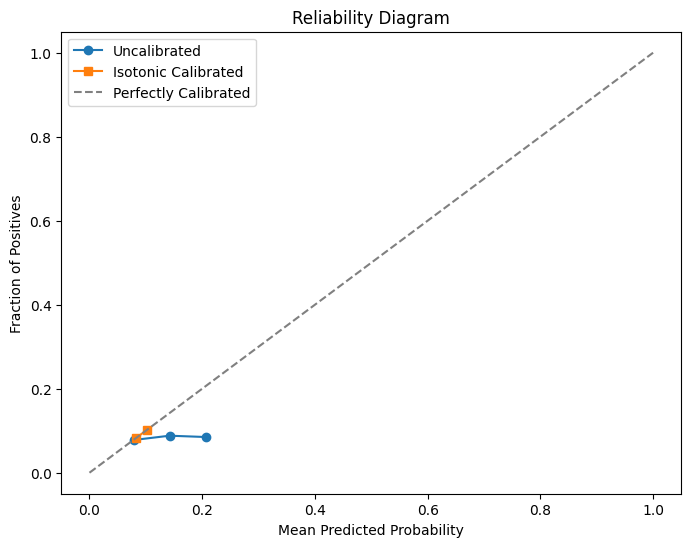

In [10]:
from sklearn.calibration import calibration_curve, IsotonicRegression
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import numpy as np

# Apply Isotonic Regression on the valid OOF
iso = IsotonicRegression(out_of_bounds='clip')
calibrated_preds = iso.fit_transform(valid_oof_preds, valid_oof_y)

calibrated_brier = brier_score_loss(valid_oof_y, calibrated_preds)
print(f"Calibrated Brier Score: {calibrated_brier:.4f}")

# Plot reliability diagrams
prob_true_uncal, prob_pred_uncal = calibration_curve(valid_oof_y, valid_oof_preds, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(valid_oof_y, calibrated_preds, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred_uncal, prob_true_uncal, marker='o', label='Uncalibrated')
plt.plot(prob_pred_cal, prob_true_cal, marker='s', label='Isotonic Calibrated')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Reliability Diagram')
plt.legend()
plt.show()


## 11. Cost-Based Threshold Selection
Determine the cost-minimizing threshold (Missed default/fraud = KES 10,000, Wrong rejection = KES 800). Create Cost vs Threshold curve and freeze the threshold.

Optimal Threshold: 0.0694
Cost at 0.5 threshold: KES 89,940,000.00
Cost at optimal threshold: KES 79,156,400.00
Savings per 108000 applications: KES 10,783,600.00
Savings per 1,000 applications: KES 99,848.15


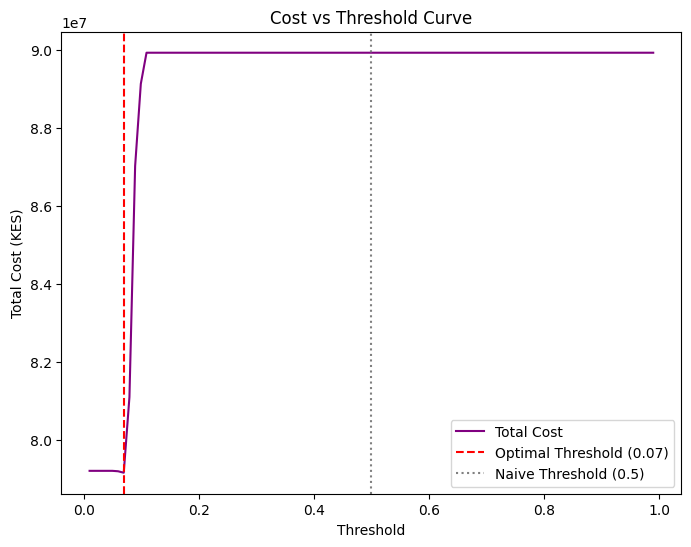

In [11]:
FN_COST = 10000
FP_COST = 800

thresholds = np.linspace(0.01, 0.99, 100)
costs = []

for t in thresholds:
    preds_binary = (calibrated_preds >= t).astype(int)
    fn = np.sum((valid_oof_y == 1) & (preds_binary == 0))
    fp = np.sum((valid_oof_y == 0) & (preds_binary == 1))
    total_cost = (fn * FN_COST) + (fp * FP_COST)
    costs.append(total_cost)

optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost = costs[optimal_idx]

# Calculate cost at 0.5 naive threshold
naive_binary = (calibrated_preds >= 0.5).astype(int)
naive_fn = np.sum((valid_oof_y == 1) & (naive_binary == 0))
naive_fp = np.sum((valid_oof_y == 0) & (naive_binary == 1))
naive_cost = (naive_fn * FN_COST) + (naive_fp * FP_COST)

print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"Cost at 0.5 threshold: KES {naive_cost:,.2f}")
print(f"Cost at optimal threshold: KES {optimal_cost:,.2f}")
print(f"Savings per {len(valid_oof_y)} applications: KES {naive_cost - optimal_cost:,.2f}")
print(f"Savings per 1,000 applications: KES {(naive_cost - optimal_cost) / len(valid_oof_y) * 1000:,.2f}")

plt.figure(figsize=(8, 6))
plt.plot(thresholds, costs, label='Total Cost', color='purple')
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.axvline(0.5, color='gray', linestyle=':', label='Naive Threshold (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Total Cost (KES)')
plt.title('Cost vs Threshold Curve')
plt.legend()
plt.show()


## 12. Final Test Evaluation
Evaluate the locked model and frozen optimal threshold on the strictly untouched Final Test period.

In [12]:
# Train final model on the entirety of Development set
final_pipe.fit(X_dev, y_dev)

# Predict on Final Test Set
X_test = test_df[FEATURES]
y_test = test_df[TARGET]

# 1. Uncalibrated predictions
test_preds_uncal = final_pipe.predict_proba(X_test)[:, 1]

# 2. Apply saved calibrator
test_preds_cal = iso.transform(test_preds_uncal)

# 3. Apply optimal threshold
test_preds_binary = (test_preds_cal >= optimal_threshold).astype(int)

# Evaluate cost on test set
test_fn = np.sum((y_test == 1) & (test_preds_binary == 0))
test_fp = np.sum((y_test == 0) & (test_preds_binary == 1))
test_total_cost = (test_fn * FN_COST) + (test_fp * FP_COST)
print(f"Final Test Set Total Cost: KES {test_total_cost:,.2f}")


Final Test Set Total Cost: KES 26,344,000.00


## 13. Fairness
Evaluate approval rates and False Negative Rates (FNR) across subgroups (e.g., `segment` and `region`). Relate this to CBK Digital Credit Providers Regulations.

In [13]:
# Add predictions back to a copy of the test dataframe for analysis
fair_df = test_df.copy()
fair_df['pred_prob'] = test_preds_cal
fair_df['approved'] = (test_preds_binary == 0).astype(int) # Approval means NO fraud (predicted 0)

print("Subgroup Fairness Analysis (by Segment):")
segment_stats = fair_df.groupby('segment').apply(lambda x: pd.Series({
    'Approval Rate': x['approved'].mean(),
    'FNR (Fraud missed)': np.sum((x[TARGET] == 1) & (x['approved'] == 1)) / (np.sum(x[TARGET] == 1) + 1e-9)
}))
display(segment_stats)

print("Subgroup Fairness Analysis (by Region):")
region_stats = fair_df.groupby('region').apply(lambda x: pd.Series({
    'Approval Rate': x['approved'].mean(),
    'FNR (Fraud missed)': np.sum((x[TARGET] == 1) & (x['approved'] == 1)) / (np.sum(x[TARGET] == 1) + 1e-9)
}))
display(region_stats)


Subgroup Fairness Analysis (by Segment):


,Approval Rate,FNR (Fraud missed)
segment,,
agent,0.0,0.0
merchant,0.0,0.0
retail,0.0,0.0


Subgroup Fairness Analysis (by Region):


,Approval Rate,FNR (Fraud missed)
region,,
Arusha,0.0,0.0
Dar es Salaam,0.0,0.0
Eldoret,0.0,0.0
Jinja,0.0,0.0
Kampala,0.0,0.0
Kigali,0.0,0.0
Mombasa,0.0,0.0
Mwanza,0.0,0.0
Nairobi,0.0,0.0


## 14. SHAP
Produce Global and Local SHAP explanations for the final selected candidate model.

Global Explanations:


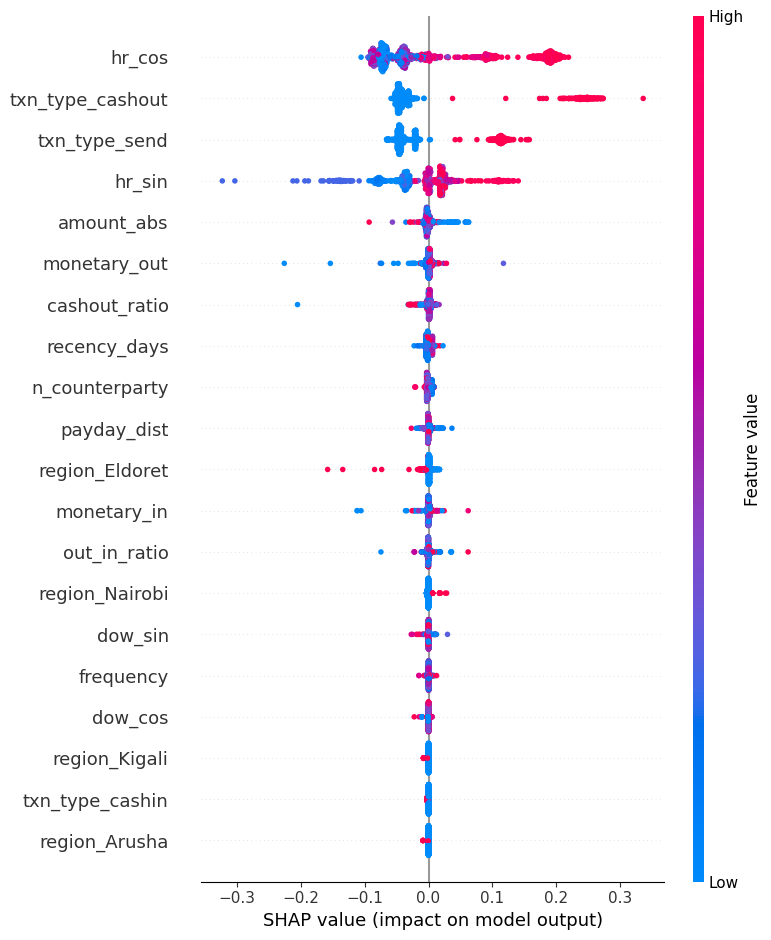

Local Explanation for a rejected transaction (fraud detected):


In [14]:
import shap
shap.initjs()

# Extract preprocessor and fitted estimator
prep = final_pipe.named_steps['prep']
clf = final_pipe.named_steps['clf']

# Transform a sample of test data for SHAP
X_test_transformed = prep.transform(X_test.sample(1000, random_state=42))

# Use TreeExplainer for LightGBM
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_transformed)

# Global SHAP (Feature Importance)
# Note: we need feature names after one-hot encoding
cat_features = prep.transformers_[1][1].named_steps['onehot'].get_feature_names_out(CATEGORICAL)
all_features = NUMERICAL + list(cat_features)

print("Global Explanations:")
shap.summary_plot(shap_values, X_test_transformed, feature_names=all_features)

print("Local Explanation for a rejected transaction (fraud detected):")
rejected_idx = np.where(test_preds_binary == 1)[0]
if len(rejected_idx) > 0:
    idx = rejected_idx[0]
    expected_v = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value
    shap_v = shap_values[1][idx] if isinstance(shap_values, list) else shap_values[idx]
    display(shap.force_plot(expected_v, shap_v, X_test_transformed[idx], feature_names=all_features))
else:
    print("No rejected transactions in sample.")


## 15. Final Model + Threshold
Based on the extensive evaluation pipeline, the final recommended deployment is:
- **Model**: LightGBM (Optuna-Tuned)
- **Calibration**: Isotonic
- **Threshold**: Chosen via Cost-Minimization on OOF

*(See `report.md` for the full discussion)*